<a href="https://colab.research.google.com/github/Arzuyasar/lendingclub-Ml/blob/main/Lending_Club_Loan_Data_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
# Bu, kod olarak biçimlendirilmiştir
```

**Loan** **Default** **Prediction**

Bir kredi başvurusunun default (ödeyememe) ile sonuçlanıp sonuçlanmayacağını tahmin ediyor.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

import shap

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [ ]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated*",
    category=FutureWarning,
)

warnings.filterwarnings(
    "ignore",
    message="When grouping with a length-1 list-like*",
    category=FutureWarning,
)

**Load** **Dataset**

In [ ]:
DATA_PATH = "/content/accepted_2007_to_2018Q4.csv"

data = pd.read_csv(DATA_PATH, low_memory=False)

data = data.sample(100000, random_state=42)

def convert_status(x):
    if x == "Fully Paid":
        return 0
    else:
        return 1

data["default_flag"] = data["loan_status"].apply(convert_status)
TARGET_COL = "default_flag"

NUMERIC_COLS = [
    "loan_amnt", "funded_amnt", "funded_amnt_inv",
    "int_rate", "installment", "annual_inc", "dti",
    "delinq_2yrs", "inq_last_6mths", "open_acc",
    "pub_rec", "revol_bal", "revol_util", "total_acc"
]

CATEGORICAL_COLS = [
    "purpose", "home_ownership",
    "verification_status", "application_type"
]

data = data[NUMERIC_COLS + CATEGORICAL_COLS + [TARGET_COL]]
data.head()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,purpose,home_ownership,verification_status,application_type,default_flag
392949,32000.0,32000.0,32000.0,10.49,687.65,120000.0,24.05,0.0,0.0,20.0,0.0,39687.0,57.8,42.0,debt_consolidation,MORTGAGE,Verified,Individual,1
1273506,9600.0,9600.0,9600.0,12.99,323.42,21900.0,10.03,0.0,1.0,13.0,1.0,4509.0,38.9,20.0,debt_consolidation,RENT,Verified,Individual,0
324024,4000.0,4000.0,4000.0,6.68,122.93,83000.0,19.53,0.0,0.0,16.0,0.0,1564.0,17.2,25.0,major_purchase,MORTGAGE,Not Verified,Individual,0
2066630,6025.0,6025.0,6025.0,10.91,197.00,52000.0,9.16,1.0,1.0,11.0,0.0,2706.0,12.8,25.0,debt_consolidation,RENT,Not Verified,Individual,0
477199,25000.0,25000.0,25000.0,26.30,752.96,65000.0,36.26,0.0,1.0,19.0,0.0,49461.0,24.7,33.0,debt_consolidation,OWN,Verified,Individual,1


**Dataset** **Summary**

In [ ]:
print(data.info())
data.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 392949 to 347653
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   loan_amnt            99996 non-null   float64
 1   funded_amnt          99996 non-null   float64
 2   funded_amnt_inv      99996 non-null   float64
 3   int_rate             99996 non-null   float64
 4   installment          99996 non-null   float64
 5   annual_inc           99996 non-null   float64
 6   dti                  99916 non-null   float64
 7   delinq_2yrs          99996 non-null   float64
 8   inq_last_6mths       99996 non-null   float64
 9   open_acc             99996 non-null   float64
 10  pub_rec              99996 non-null   float64
 11  revol_bal            99996 non-null   float64
 12  revol_util           99934 non-null   float64
 13  total_acc            99996 non-null   float64
 14  purpose              99996 non-null   object 
 15  home_ownership   

,0
loan_amnt,4
funded_amnt,4
funded_amnt_inv,4
int_rate,4
installment,4
annual_inc,4
dti,84
delinq_2yrs,4
inq_last_6mths,4
open_acc,4


**Data** **Cleaning**


*   Dropping duplicates
*   Handling missing values
*   Selecting only required columns




In [ ]:
if "int_rate" in data.columns:
    data.loc[:, "int_rate"] = (
        data["int_rate"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .astype(float)
    )

if "revol_util" in data.columns:
    data.loc[:, "revol_util"] = (
        data["revol_util"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .astype(float)
    )

for col in NUMERIC_COLS:
    data.loc[:, col] = pd.to_numeric(data[col], errors="coerce")
    data.loc[:, col] = data[col].fillna(data[col].median())


for col in CATEGORICAL_COLS:
    data.loc[:, col] = data[col].fillna("Unknown")


data.isna().sum()

,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
int_rate,0
installment,0
annual_inc,0
dti,0
delinq_2yrs,0
inq_last_6mths,0
open_acc,0


**Exploratory** **Data** **Analysis** (**EDA**)

We will plot:

*  Target distribution
*  Correlation matrix
*  Distributions of numeric features (default vs non-default)


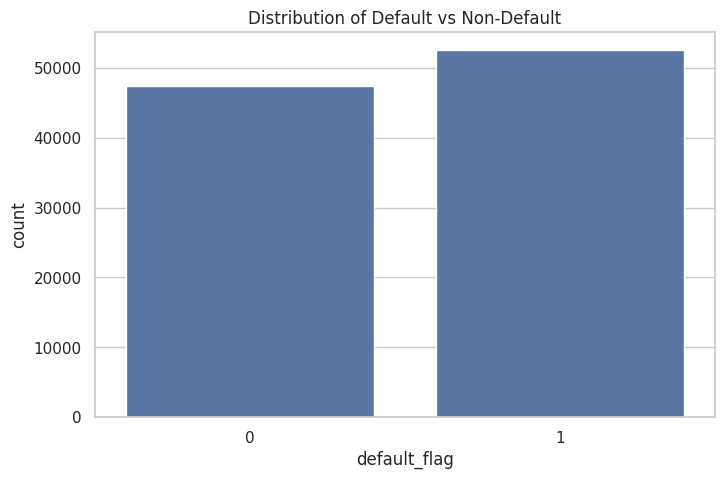

np.float64(0.5254)

In [ ]:
sns.countplot(x=data[TARGET_COL])
plt.title("Distribution of Default vs Non-Default")
plt.show()

default_rate = data[TARGET_COL].mean()
default_rate

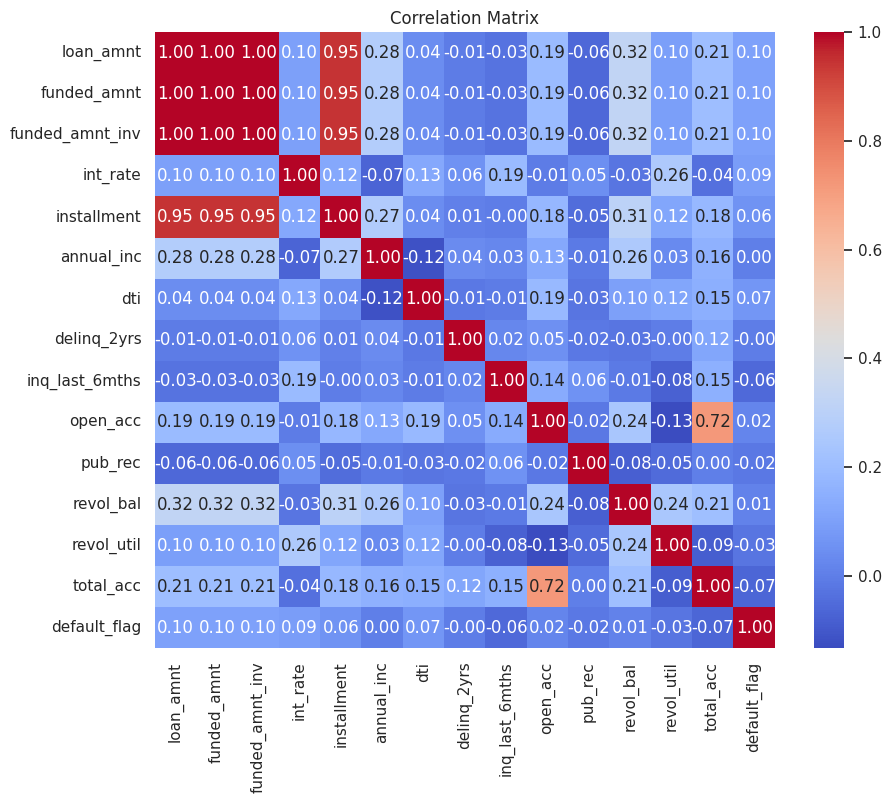

In [ ]:
numeric_available = [col for col in NUMERIC_COLS if col in data.columns]

corr = data[numeric_available + [TARGET_COL]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

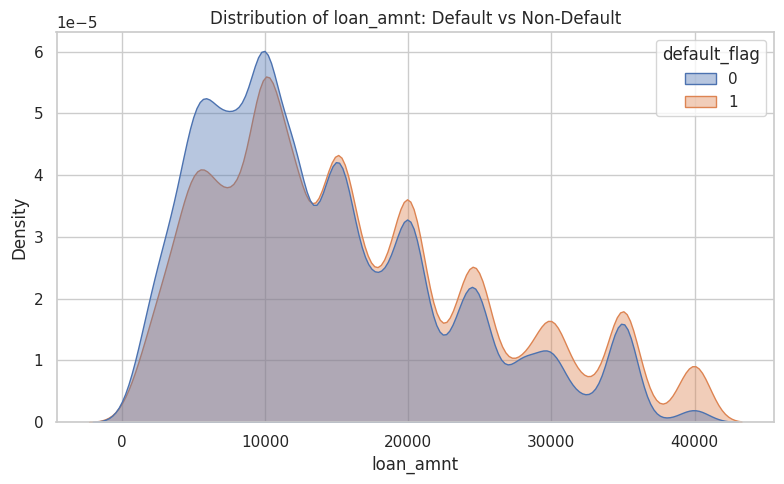

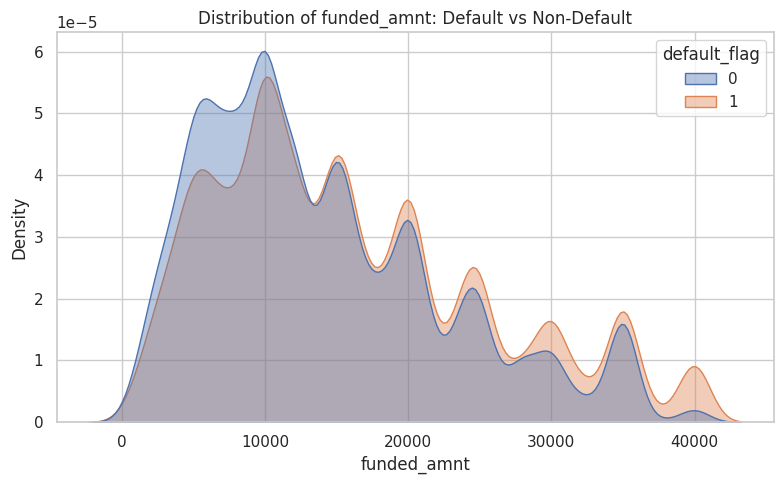

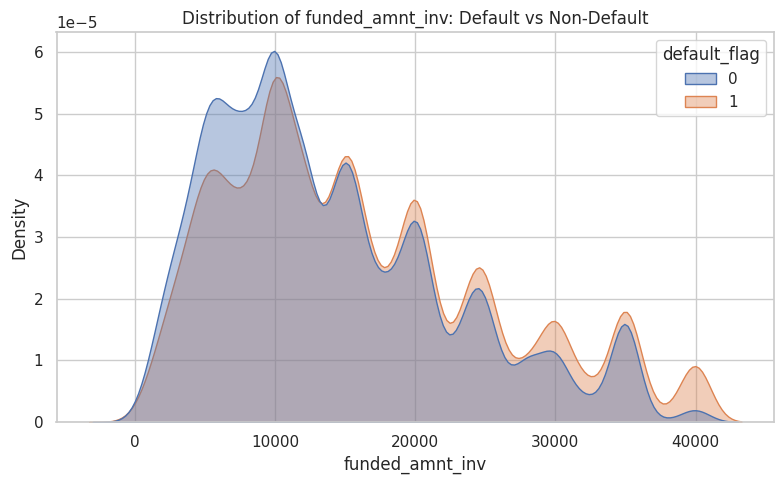

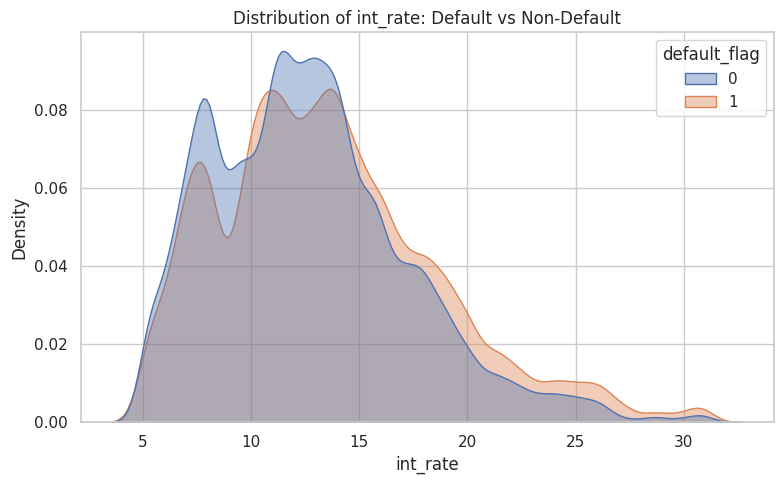

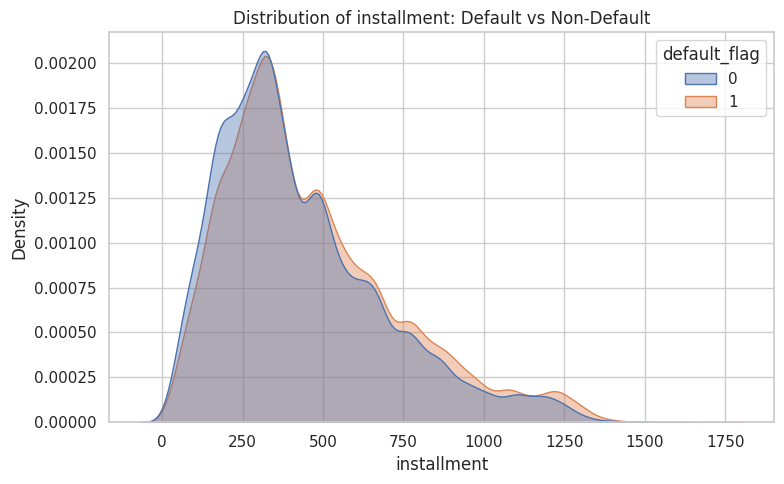

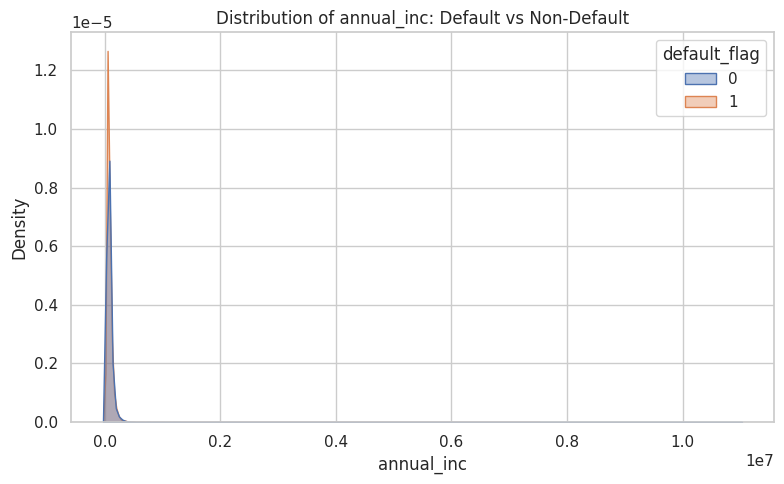

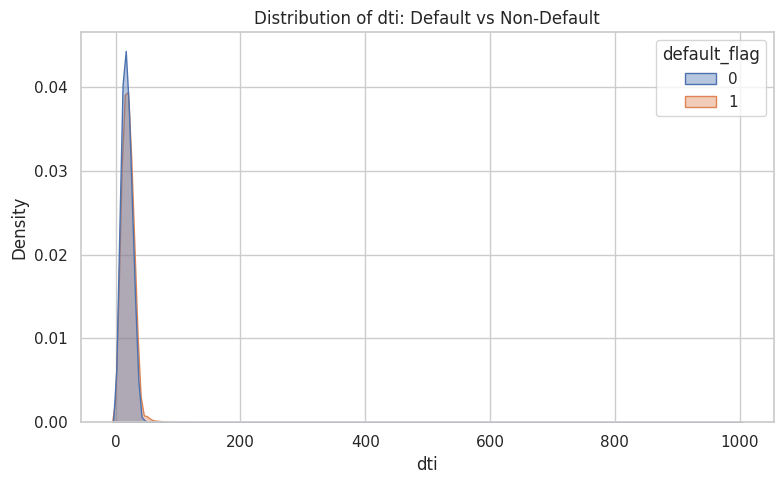

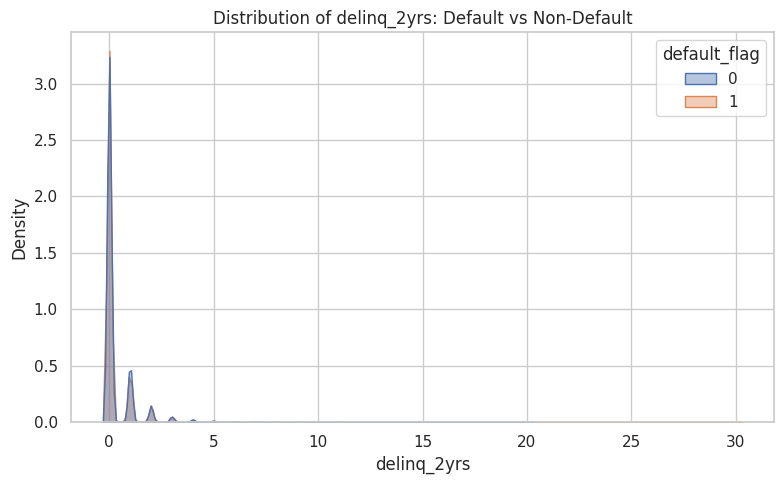

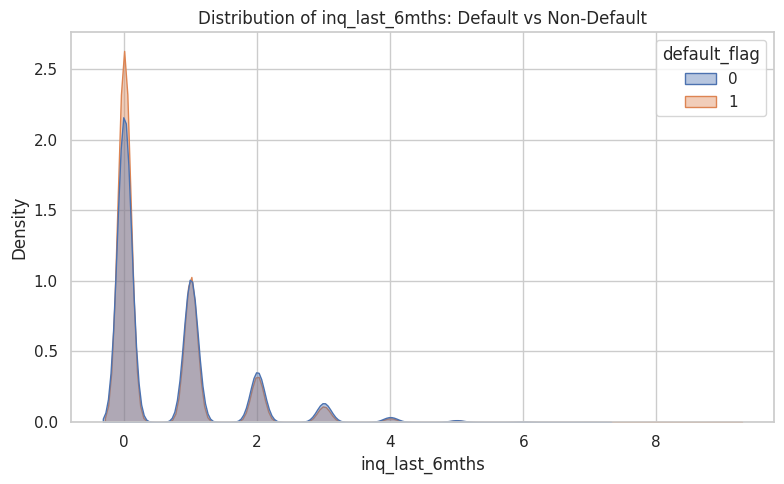

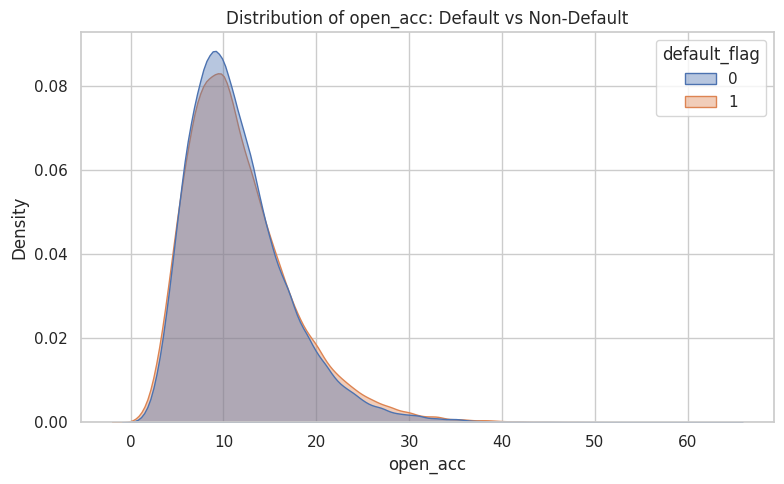

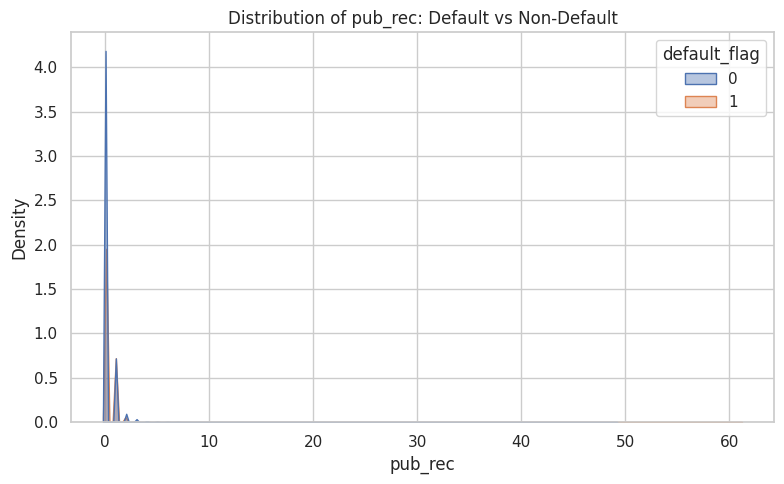

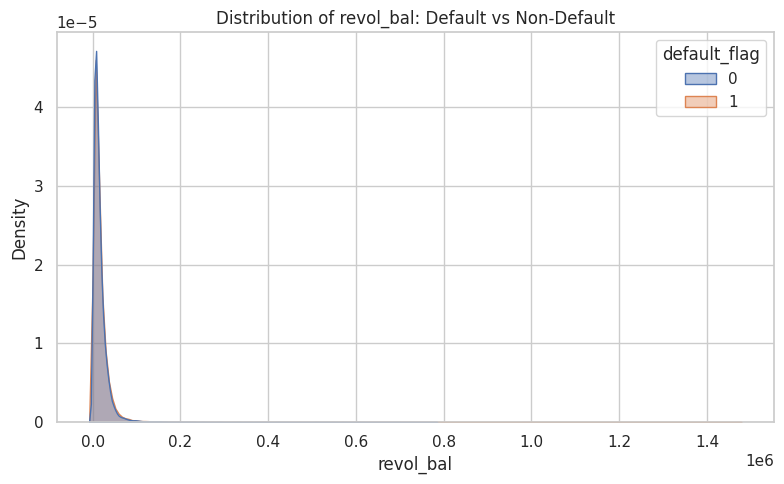

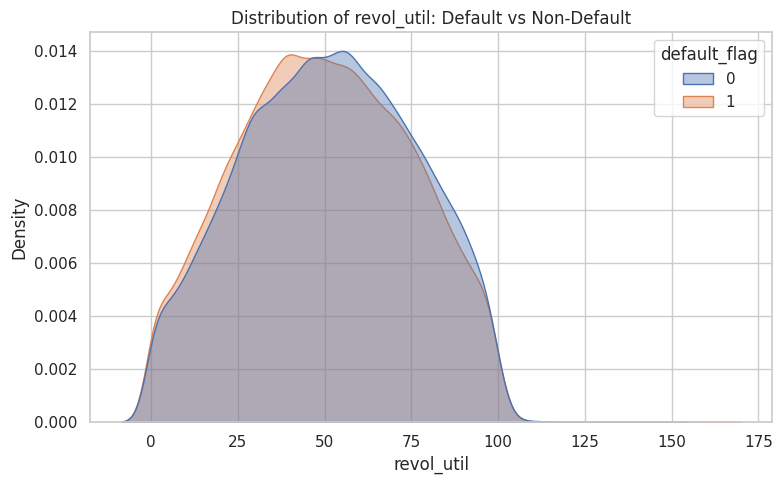

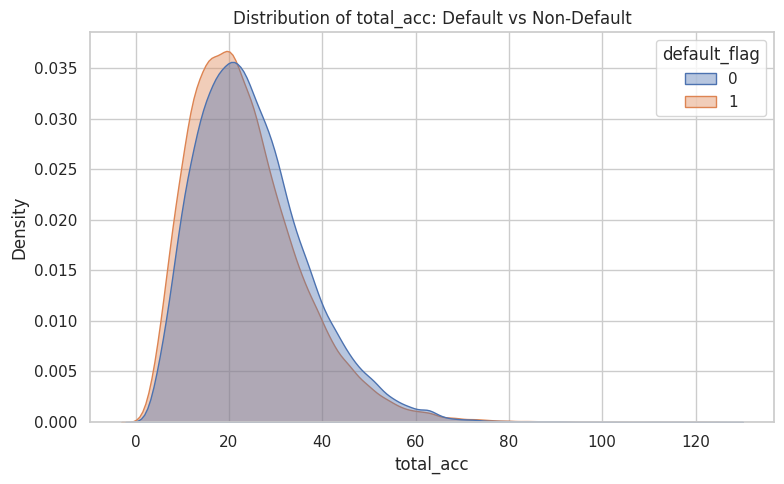

In [ ]:
for col in NUMERIC_COLS:

    if col not in data.columns:
        continue

    temp = data[[col, TARGET_COL]].dropna()
    if temp[TARGET_COL].nunique() < 2:
        continue

    plt.figure()
    sns.kdeplot(
        data=temp,
        x=col,
        hue=TARGET_COL,
        fill=True,
        common_norm=False,
        alpha=0.4
    )
    plt.title(f"Distribution of {col}: Default vs Non-Default")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

**Train–Test** **Split** **and** **Preprocessing**

We scale numeric features and one-hot encode categorical features.

In [ ]:
X = data[NUMERIC_COLS + CATEGORICAL_COLS]
y = data[TARGET_COL]

numeric_features = [c for c in NUMERIC_COLS if c in X.columns]
categorical_features = [c for c in CATEGORICAL_COLS if c in X.columns]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

**Model** **Training** — **Random** **Forest**

We use class balancing because default cases are usually rare.

In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf_clf.fit(X_train_processed, y_train)

y_pred = rf_clf.predict(X_test_processed)
y_proba = rf_clf.predict_proba(X_test_processed)[:, 1]

**Confusion** **Matrix**

Shows how well the model classifies defaults vs non-defaults.

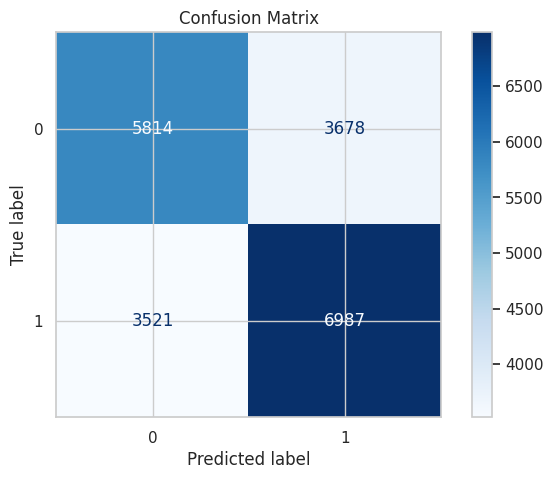

              precision    recall  f1-score   support

           0       0.62      0.61      0.62      9492
           1       0.66      0.66      0.66     10508

    accuracy                           0.64     20000
   macro avg       0.64      0.64      0.64     20000
weighted avg       0.64      0.64      0.64     20000



In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

**ROC** **Curve**

AUC > 0.80 is a good score in financial risk modeling.

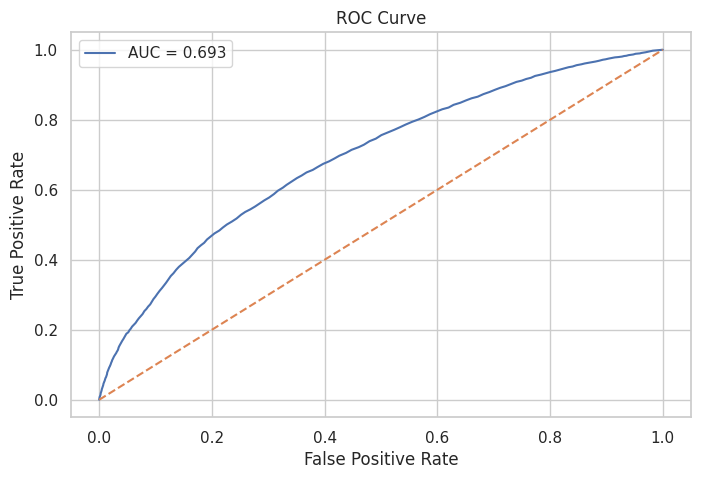

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Precision–Recall** **Curve**

Very important for imbalanced datasets (like loan defaults).

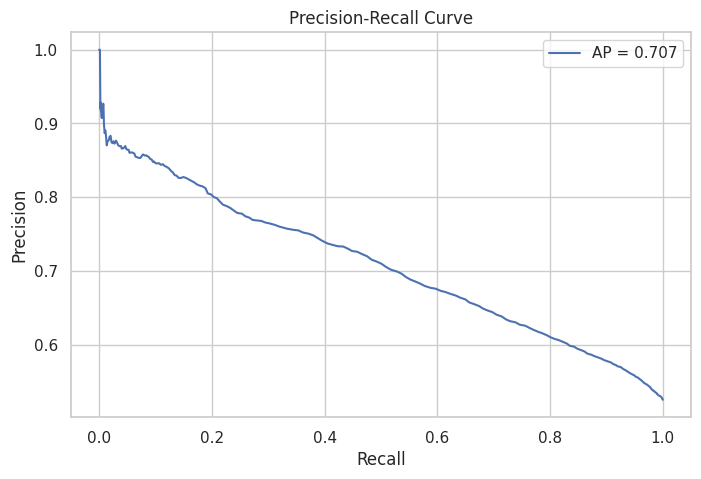

In [ ]:
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

plt.plot(recall, precision, label=f"AP = {avg_precision:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

**Feature** **Importance**

Random Forest tells us which features impact the prediction most.

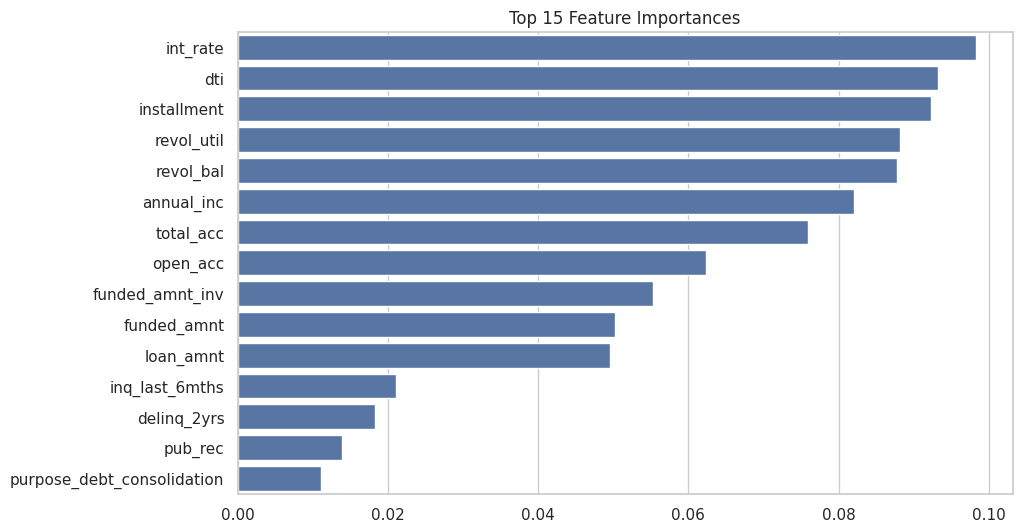

In [ ]:
feature_names_num = numeric_features

if categorical_features:
    ohe = preprocessor.named_transformers_["cat"]
    cat_names = list(ohe.get_feature_names_out(categorical_features))
else:
    cat_names = []

all_feature_names = feature_names_num + cat_names

importances = rf_clf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(
    x=importances[sorted_idx][:15],
    y=np.array(all_feature_names)[sorted_idx][:15]
)
plt.title("Top 15 Feature Importances")
plt.show()

**SHAP Summary Plot**

In [ ]:
if hasattr(X_train_processed, "toarray"):
    X_train_dense = X_train_processed.toarray()
    X_test_dense = X_test_processed.toarray()
else:
    X_train_dense = X_train_processed
    X_test_dense = X_test_processed

explainer = shap.TreeExplainer(rf_clf)
shap_values = explainer.shap_values(X_test_dense)

shap.summary_plot(
    shap_values[1],
    X_test_dense,
    feature_names=all_feature_names,
    show=True
)

**PowerBI için CSV**

In [ ]:
results = X_test.copy()
results["Actual"] = y_test.values
results["Predicted"] = y_pred
results["Probability"] = y_proba

results.to_csv("model_results.csv", index=False)